# OPC

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
import tensorflow as tf
import numpy as np


from tensorflow.keras.layers import Input, Dense

df = pd.read_excel('CRACK DETECTION TRAIL FEB 2025.xlsx')

X = df.drop(columns=['Conductance At FAILURE']).values
y = df['Conductance At FAILURE'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [2]:
input_dim = X.shape[1]
latent_dim=4

In [3]:
inputs = Input(shape=(input_dim,))
x=Dense(32,activation='relu',name='encoder_dense_1')(inputs)
x=Dense(16,activation='relu',name='encoder_dense_2')(x)
encoded=Dense(latent_dim,activation='relu',name='encoded')(x)

x=Dense(16,activation='relu',name='decoder_dense_1')(encoded)
x=Dense(32,activation='relu',name='decoder_dense_2')(x)
decoded=Dense(input_dim,activation='linear',name='decoded')(x)

pred = Dense(8, activation='relu',name='prediction_dense_1')(encoded)
pred = Dense(1, activation='linear',name='predictions')(pred)

In [4]:
autoencoder = Model(inputs=inputs, outputs=[decoded, pred])
autoencoder.compile(optimizer='adam',
                    loss={'decoded': 'mse', 'predictions': 'mse'},  # Match output layer names
                    loss_weights={'decoded': 0.5, 'predictions': 1.5})  # Match output layer names

In [5]:
history = autoencoder.fit(X_train, {'decoded':X_train, 'predictions':y_train},
                          epochs=100,
                          batch_size=32,
                          shuffle=True,
                          validation_data=(X_test, {'decoded':X_test, 'predictions':y_test}))


Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step - decoded_loss: 0.9464 - loss: 6.8176 - predictions_loss: 4.5453 - val_decoded_loss: 0.1827 - val_loss: 2.7131 - val_predictions_loss: 1.7479
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - decoded_loss: 1.3850 - loss: 10.5075 - predictions_loss: 6.0755 - val_decoded_loss: 0.1826 - val_loss: 2.5502 - val_predictions_loss: 1.6392
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - decoded_loss: 1.1758 - loss: 6.1274 - predictions_loss: 4.5532 - val_decoded_loss: 0.1826 - val_loss: 2.4091 - val_predictions_loss: 1.5452
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - decoded_loss: 1.3859 - loss: 8.0979 - predictions_loss: 4.6246 - val_decoded_loss: 0.1821 - val_loss: 2.2676 - val_predictions_loss: 1.4510
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - decoded_loss: 1.0637 - loss: 6.0937 - predictions_loss: 3.3914 - val_decoded_loss: 0.1812 - val_loss: 2.1364 - val_predictions_loss: 1.3639
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0

In [6]:
reconstructed_X, y_pred = autoencoder.predict(X_test)
mae = tf.keras.losses.MAE(y_test, y_pred.flatten()).numpy()  # Updated line to use tf.keras.losses.MAE
print(f"\nTest MAE: {mae:.4f}")

sample = X_test[0]
recon, pred = autoencoder.predict(np.array([sample]))
print(f"\nSample Prediction: {pred[0][0]:.4f} | True Value: {y_test[0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step

Test MAE: 0.1773
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step

Sample Prediction: 0.2934 | True Value: 0.2772


In [7]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


reconstructed_X, y_pred = autoencoder.predict(X_test)

mae = mean_absolute_error(y_test, y_pred.flatten())

mse = mean_squared_error(y_test, y_pred.flatten())
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred.flatten())

print(f"\nTest MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R-squared: {r2:.4f}")

sample = X_test[0]
recon, pred = autoencoder.predict(np.array([sample]))
print(f"\nSample Prediction: {pred[0][0]:.4f} | True Value: {y_test[0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Test MAE: 0.1773
Test RMSE: 0.6499
Test R-squared: 0.7710
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Sample Prediction: 0.2934 | True Value: 0.2772


In [8]:
initial_threshold = 0.7
Target_mean = df['Conductance At FAILURE'].mean()
Target_std = df['Conductance At FAILURE'].std()
print(f" At FAILURE Mean: {Target_mean}")
print(f"Conductance At FAILURE Deviation: {Target_std}")
adjusted_threshold = Target_mean + Target_std

 At FAILURE Mean: 0.6379620695513004
Conductance At FAILURE Deviation: 2.468065131850027


In [9]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



y_pred_binary = (y_pred.flatten() > adjusted_threshold).astype(int)
y_test_binary = (y_test > initial_threshold).astype(int)

accuracy = accuracy_score(y_test_binary, y_pred_binary)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_binary))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_binary))



Accuracy: 0.9500

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.50      0.67         2

    accuracy                           0.95        20
   macro avg       0.97      0.75      0.82        20
weighted avg       0.95      0.95      0.94        20


Confusion Matrix:
[[18  0]
 [ 1  1]]


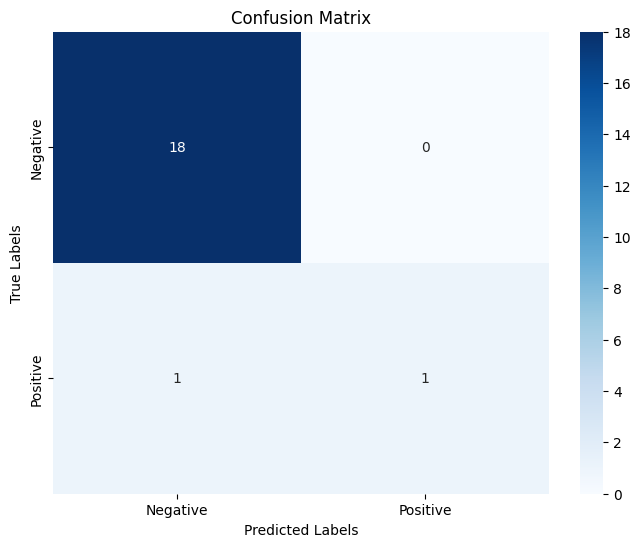

In [10]:

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_binary, y_pred_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


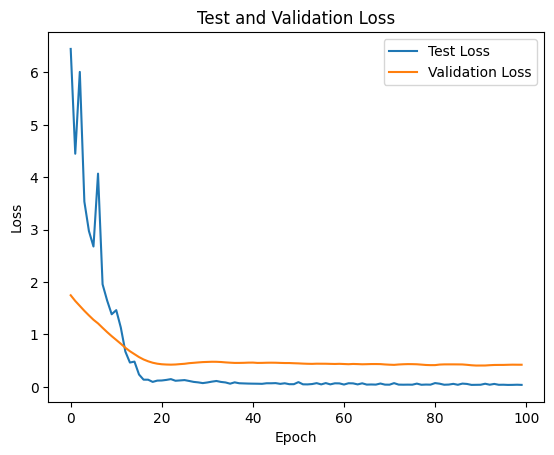

In [11]:

import matplotlib.pyplot as plt
plt.plot(history.history['predictions_loss'], label='Test Loss')
plt.plot(history.history['val_predictions_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Test and Validation Loss')
plt.show()


In [12]:

import numpy as np
sample = X_test[0]
recon, pred = autoencoder.predict(np.array([sample]))

adjusted_threshold = Target_mean + Target_std
if pred[0][0] > adjusted_threshold:
    print("Cracked")
else:
    print("Not Cracked")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Not Cracked


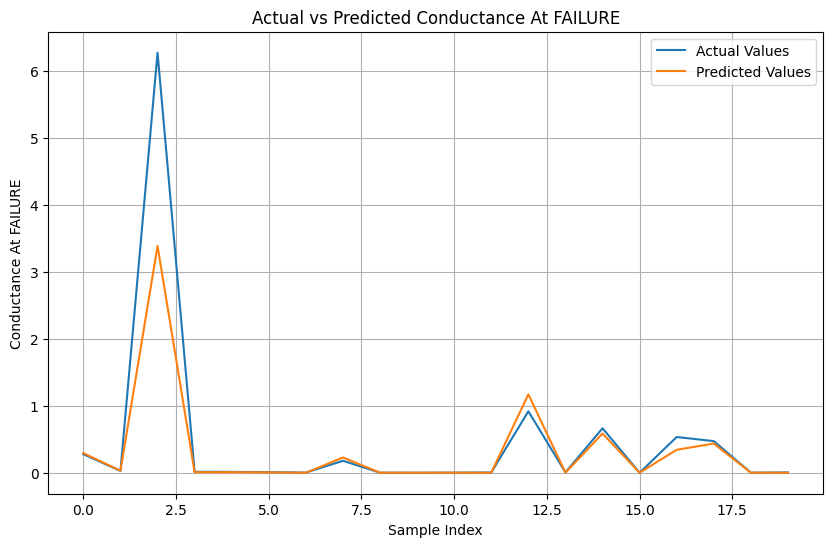

In [13]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual Values')
plt.plot(y_pred.flatten(), label='Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('Conductance At FAILURE')
plt.title('Actual vs Predicted Conductance At FAILURE')
plt.legend()
plt.grid(True)
plt.show()


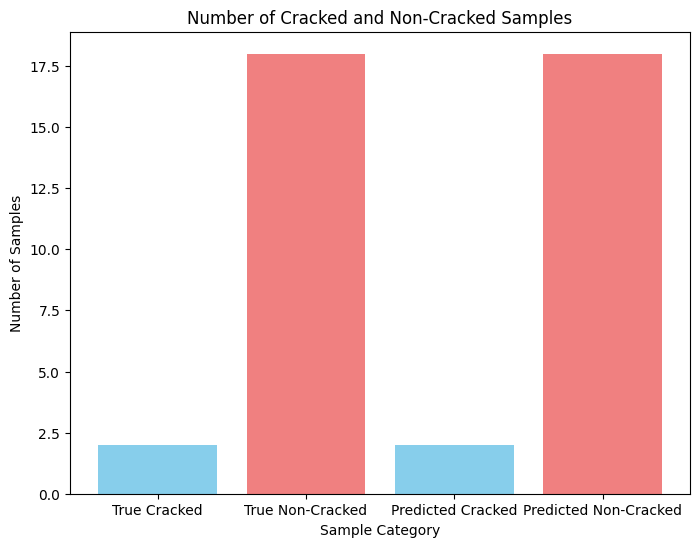

In [28]:

import matplotlib.pyplot as plt


cracked_true = sum(y_test_binary)
non_cracked_true = len(y_test_binary) - cracked_true
cracked_pred = sum(y_pred_binary)
non_cracked_pred = len(y_pred_binary) - cracked_pred


labels = ['True Cracked', 'True Non-Cracked', 'Predicted Cracked', 'Predicted Non-Cracked']
values = [cracked_true, non_cracked_true, cracked_pred, non_cracked_pred]
plt.figure(figsize=(8, 6))
plt.bar(labels, values, color=['skyblue', 'lightcoral', 'skyblue', 'lightcoral'])
plt.title('Number of Cracked and Non-Cracked Samples')
plt.xlabel('Sample Category')
plt.ylabel('Number of Samples')
plt.show()


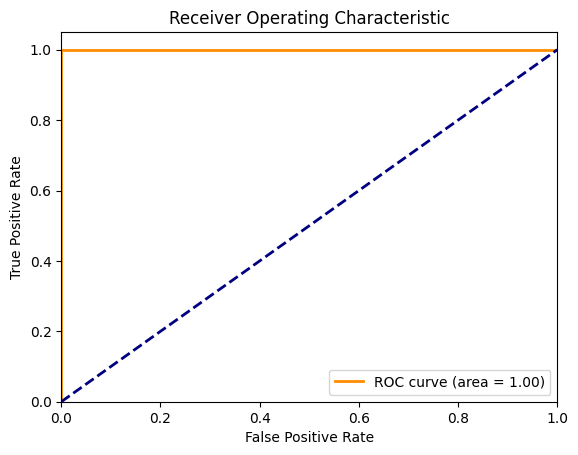

In [30]:

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred.flatten())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


# PPC

In [15]:
df = pd.read_excel('PPC CRACK DETECTION 2025.xlsx')
df.head()


,FREQUENCE (kHz),UNDAMAGED,10 UL,20 UL,30 UL,40 UL,50 UL,60 UL,70 UL,80 UL,90 UL,FAILURE
0,1.0000,0.002747,0.015631,0.013737,0.015837,0.012807,0.015161,0.015753,0.014087,0.014087,0.018903,0.016175
1,1.0648,0.002747,0.015605,0.013735,0.015808,0.012827,0.015157,0.015750,0.014110,0.014110,0.018900,0.016217
2,1.1339,0.002747,0.015582,0.013735,0.015793,0.012857,0.015165,0.015751,0.014143,0.014143,0.018901,0.016266
3,1.2074,0.002750,0.015582,0.013752,0.015786,0.012900,0.015185,0.015768,0.014190,0.014190,0.018921,0.016331
4,1.2856,0.002757,0.015588,0.013785,0.015794,0.012948,0.015217,0.015798,0.014243,0.014243,0.018957,0.016404


In [16]:
X = df.drop(columns=['FAILURE']).values
y = df['FAILURE'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
input_dim = X.shape[1]
latent_dim=4

In [18]:
inputs = Input(shape=(input_dim,))
x=Dense(32,activation='relu',name='encoder_dense_1')(inputs)
x=Dense(16,activation='relu',name='encoder_dense_2')(x)
encoded=Dense(latent_dim,activation='relu',name='encoded')(x)

x=Dense(16,activation='relu',name='decoder_dense_1')(encoded)
x=Dense(32,activation='relu',name='decoder_dense_2')(x)
decoded=Dense(input_dim,activation='linear',name='decoded')(x)

pred = Dense(8, activation='relu',name='prediction_dense_1')(encoded)
pred = Dense(1, activation='linear',name='predictions')(pred)

In [19]:
autoencoder = Model(inputs=inputs, outputs=[decoded, pred])
autoencoder.compile(optimizer='adam',
                    loss={'decoded': 'mse', 'predictions': 'mse'},  # Match output layer names
                    loss_weights={'decoded': 0.5, 'predictions': 1.5})  # Match output layer names

In [20]:
history = autoencoder.fit(X_train, {'decoded':X_train, 'predictions':y_train},
                          epochs=100,
                          batch_size=32,
                          shuffle=True,
                          validation_data=(X_test, {'decoded':X_test, 'predictions':y_test}))


Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - decoded_loss: 0.6707 - loss: 1.6528 - predictions_loss: 0.8097 - val_decoded_loss: 1.5250 - val_loss: 3.4356 - val_predictions_loss: 1.7821
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - decoded_loss: 0.6632 - loss: 1.3286 - predictions_loss: 0.6663 - val_decoded_loss: 1.4922 - val_loss: 3.0082 - val_predictions_loss: 1.5081
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - decoded_loss: 0.7906 - loss: 1.4465 - predictions_loss: 0.6516 - val_decoded_loss: 1.4525 - val_loss: 2.5693 - val_predictions_loss: 1.2287
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - decoded_loss: 0.8355 - loss: 1.2826 - predictions_loss: 0.5454 - val_decoded_loss: 1.4087 - val_loss: 2.1367 - val_predictions_loss: 0.9549
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - decoded_loss: 0.6759 - loss: 0.9150 - predictions_loss: 0.3610 - val_decoded_loss: 1.3615 - val_loss: 1.7217 - val_predictions_loss: 0.6940
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s

In [21]:
reconstructed_X, y_pred = autoencoder.predict(X_test)
mae = tf.keras.losses.MAE(y_test, y_pred.flatten()).numpy()  # Updated line to use tf.keras.losses.MAE
print(f"\nTest MAE: {mae:.4f}")

sample = X_test[0]
recon, pred = autoencoder.predict(np.array([sample]))
print(f"\nSample Prediction: {pred[0][0]:.4f} | True Value: {y_test[0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step

Test MAE: 0.0265
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step

Sample Prediction: 0.6317 | True Value: 0.6399


In [23]:
initial_threshold = 0.7
Target_mean = df['FAILURE'].mean()
Target_std = df['FAILURE'].std()
print(f" At FAILURE Mean: {Target_mean}")
print(f"Conductance At FAILURE Deviation: {Target_std}")
adjusted_threshold = Target_mean + Target_std

 At FAILURE Mean: 0.627511151596762
Conductance At FAILURE Deviation: 1.3081286727182357


In [24]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



y_pred_binary = (y_pred.flatten() > adjusted_threshold).astype(int)
y_test_binary = (y_test > initial_threshold).astype(int)

accuracy = accuracy_score(y_test_binary, y_pred_binary)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_binary))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_binary))



Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00         2

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Confusion Matrix:
[[18  0]
 [ 0  2]]


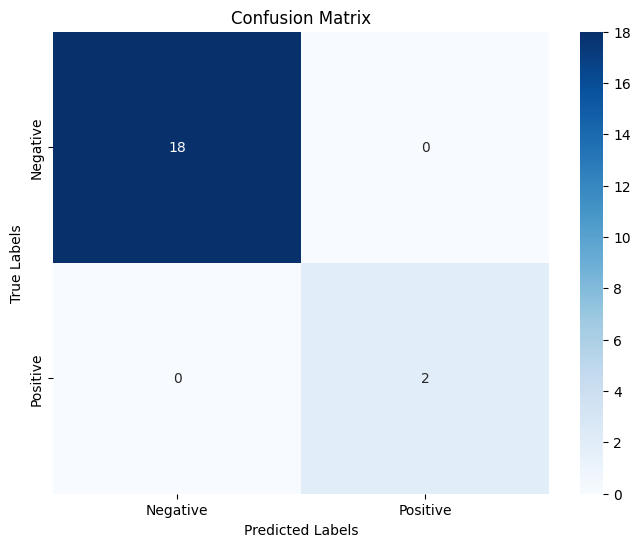

In [25]:

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_binary, y_pred_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


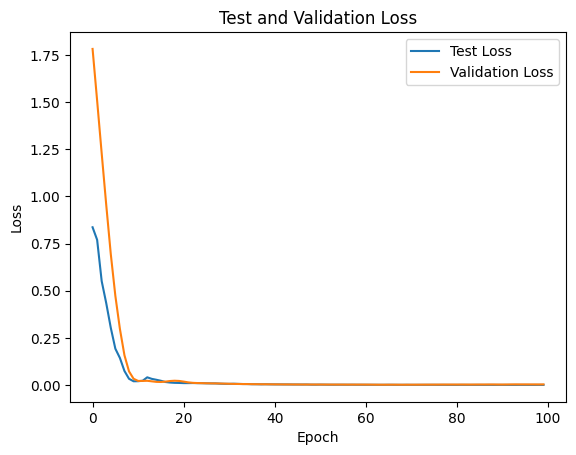

In [26]:

import matplotlib.pyplot as plt
plt.plot(history.history['predictions_loss'], label='Test Loss')
plt.plot(history.history['val_predictions_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Test and Validation Loss')
plt.show()


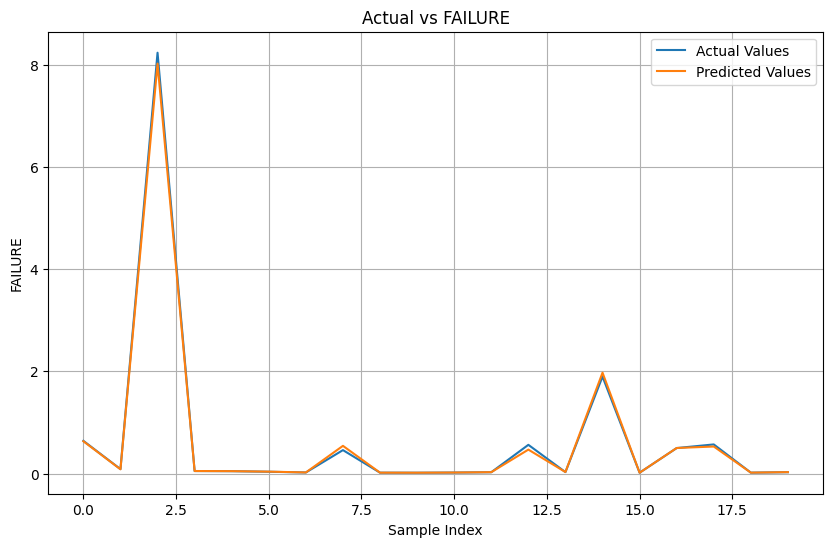

In [27]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual Values')
plt.plot(y_pred.flatten(), label='Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('FAILURE')
plt.title('Actual vs FAILURE')
plt.legend()
plt.grid(True)
plt.show()


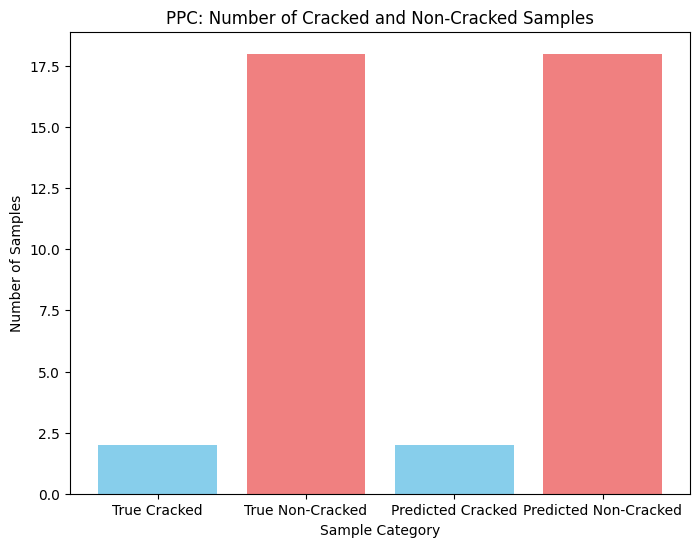

In [34]:
# prompt: plot number of non cracked and cracked in both actual and predicted in ppc

import matplotlib.pyplot as plt
cracked_true_ppc = sum(y_test_binary)
non_cracked_true_ppc = len(y_test_binary) - cracked_true_ppc
cracked_pred_ppc = sum(y_pred_binary)
non_cracked_pred_ppc = len(y_pred_binary) - cracked_pred_ppc

labels = ['True Cracked', 'True Non-Cracked', 'Predicted Cracked', 'Predicted Non-Cracked']
values_ppc = [cracked_true_ppc, non_cracked_true_ppc, cracked_pred_ppc, non_cracked_pred_ppc]

plt.figure(figsize=(8, 6))
plt.bar(labels, values_ppc, color=['skyblue', 'lightcoral', 'skyblue', 'lightcoral'])
plt.title('PPC: Number of Cracked and Non-Cracked Samples')
plt.xlabel('Sample Category')
plt.ylabel('Number of Samples')
plt.show()


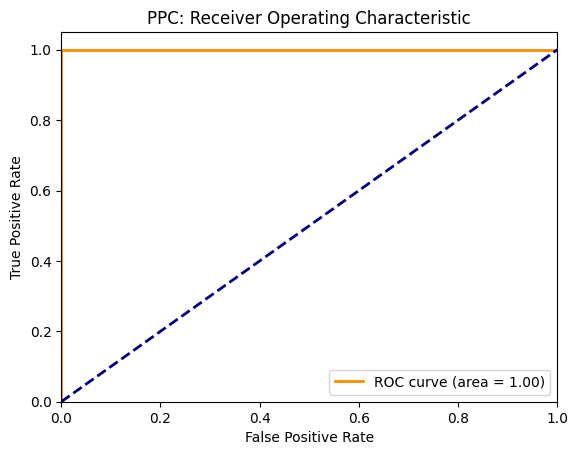

In [36]:
# prompt: plot ppc roc curve

import matplotlib.pyplot as plt
fpr_ppc, tpr_ppc, thresholds_ppc = roc_curve(y_test_binary, y_pred.flatten())
roc_auc_ppc = auc(fpr_ppc, tpr_ppc)

plt.figure()
plt.plot(fpr_ppc, tpr_ppc, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_ppc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('PPC: Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


# FRC

In [55]:
df1 = pd.read_excel('FRC CRACK DETECTION 2025.xlsx')
df.head()

,FREQUENCE (kHz),UNDAMAGED,10 UL,20 UL,30 UL,40 UL,50 UL,60 UL,70 UL,80 UL,90 UL,FAILURE
0,1.0000,0.255375,0.163440,0.204300,0.224730,0.247203,0.189380,0.306450,0.227256,0.246194,0.320053,0.416069
1,1.0648,0.256098,0.163902,0.204878,0.225366,0.247903,0.189955,0.307317,0.227946,0.246942,0.321024,0.417331
2,1.1339,0.256639,0.164249,0.205311,0.225842,0.248426,0.190480,0.307966,0.228576,0.247624,0.321911,0.418484
3,1.2074,0.257042,0.164507,0.205634,0.226197,0.248817,0.190974,0.308451,0.229169,0.248266,0.322746,0.419570
4,1.2856,0.257304,0.164674,0.205843,0.226427,0.249070,0.191441,0.308764,0.229729,0.248873,0.323535,0.420595


In [70]:
X = df1.drop(columns=['FAILURE']).values
y = df1['FAILURE'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [71]:
input_dim = X.shape[1]
latent_dim=4

In [97]:
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

# Define your model architecture
inputs = Input(shape=(input_dim,))

# Encoder
x = Dense(128, activation='elu', kernel_regularizer=l2(1e-4))(inputs)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation='elu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

encoded = Dense(latent_dim, activation='elu')(x)

# Decoder
x = Dense(64, activation='elu', kernel_regularizer=l2(1e-4))(encoded)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(128, activation='elu', kernel_regularizer=l2(1e-4))(x)
decoded = Dense(input_dim, activation='linear', name='decoded')(x)

# Prediction Head
pred = Dense(64, activation='elu', kernel_regularizer=l2(1e-4))(encoded)
pred = BatchNormalization()(pred)
pred = Dropout(0.3)(pred)

pred = Dense(32, activation='elu', kernel_regularizer=l2(1e-4))(pred)
predictions = Dense(1, activation='linear', name='predictions')(pred)

# Create model
autoencoder = Model(inputs=inputs, outputs=[decoded, predictions])

# COMPILE THE MODEL (this was missing)
autoencoder.compile(
    optimizer='adam',
    loss={'decoded': 'mse', 'predictions': 'mse'},
    loss_weights={'decoded': 0.3, 'predictions': 1.7},
    metrics={'predictions': ['mae', 'mse']}
)

# Now you can fit the model
history = autoencoder.fit(
    X_train,
    {'decoded': X_train, 'predictions': y_train},
    epochs=300,
    batch_size=16,
    validation_data=(X_test, {'decoded': X_test, 'predictions': y_test}),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=15),
        tf.keras.callbacks.ReduceLROnPlateau(patience=5)
    ]
)

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 155ms/step - decoded_loss: 2.0321 - loss: 55.1957 - predictions_loss: 32.0947 - predictions_mae: 3.3523 - predictions_mse: 32.0947 - val_decoded_loss: 0.4285 - val_loss: 34.8116 - val_predictions_loss: 13.9285 - val_predictions_mae: 2.4538 - val_predictions_mse: 20.3543 - learning_rate: 0.0010
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - decoded_loss: 1.1335 - loss: 23.2711 - predictions_loss: 13.4741 - predictions_mae: 2.6375 - predictions_mse: 13.4741 - val_decoded_loss: 0.3514 - val_loss: 33.0081 - val_predictions_loss: 13.2910 - val_predictions_mae: 2.5247 - val_predictions_mse: 19.3105 - learning_rate: 0.0010
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - decoded_loss: 1.0862 - loss: 27.4472 - predictions_loss: 15.9390 - predictions_mae: 2.6183 - predictions_mse: 15.9390 - val_decoded_loss: 0.2649 - val_loss: 31.4739 - val_predictions_loss: 12.7578 - val_predictions_mae: 2.5428 - val_predictions_mse: 18.4284 - learning_rate: 0.00

In [98]:
initial_threshold = 0.7
Target_mean = df1['FAILURE'].mean()
Target_std = df1['FAILURE'].std()
print(f" At FAILURE Mean: {Target_mean}")
print(f"Conductance At FAILURE Deviation: {Target_std}")
adjusted_threshold = Target_mean + Target_std

 At FAILURE Mean: 2.723663480798562
Conductance At FAILURE Deviation: 4.045817815142255


In [99]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



y_pred_binary = (y_pred.flatten() > adjusted_threshold).astype(int)
y_test_binary = (y_test > initial_threshold).astype(int)

accuracy = accuracy_score(y_test_binary, y_pred_binary)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_binary))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, y_pred_binary))



Accuracy: 0.6500

Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77        12
           1       1.00      0.12      0.22         8

    accuracy                           0.65        20
   macro avg       0.82      0.56      0.50        20
weighted avg       0.78      0.65      0.55        20


Confusion Matrix:
[[12  0]
 [ 7  1]]


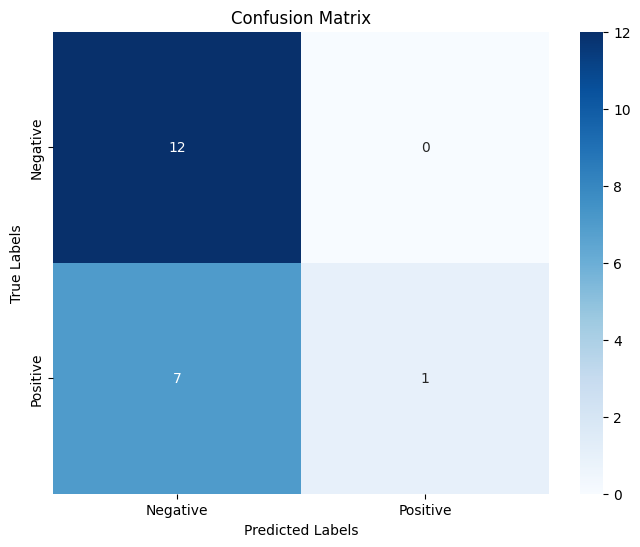

In [100]:

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_binary, y_pred_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


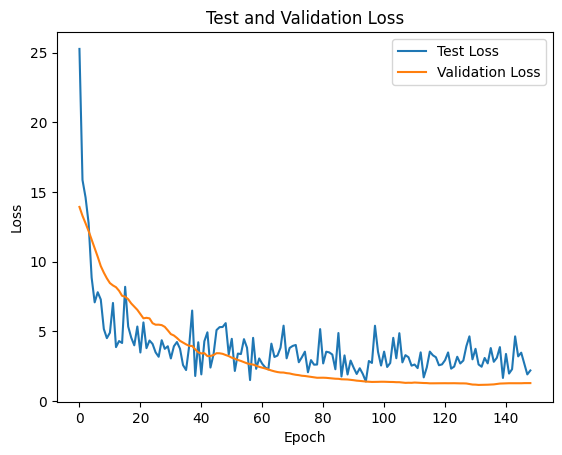

In [101]:

import matplotlib.pyplot as plt
plt.plot(history.history['predictions_loss'], label='Test Loss')
plt.plot(history.history['val_predictions_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Test and Validation Loss')
plt.show()


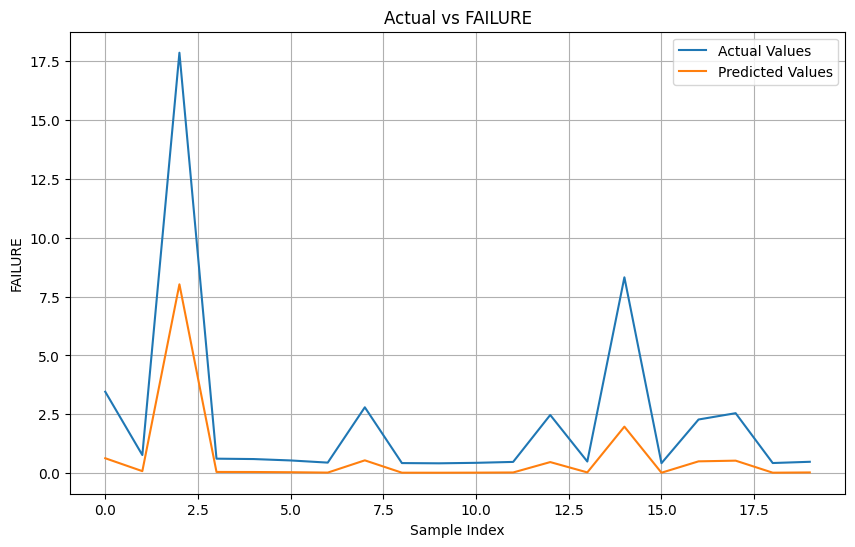

In [102]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual Values')
plt.plot(y_pred.flatten(), label='Predicted Values')
plt.xlabel('Sample Index')
plt.ylabel('FAILURE')
plt.title('Actual vs FAILURE')
plt.legend()
plt.grid(True)
plt.show()


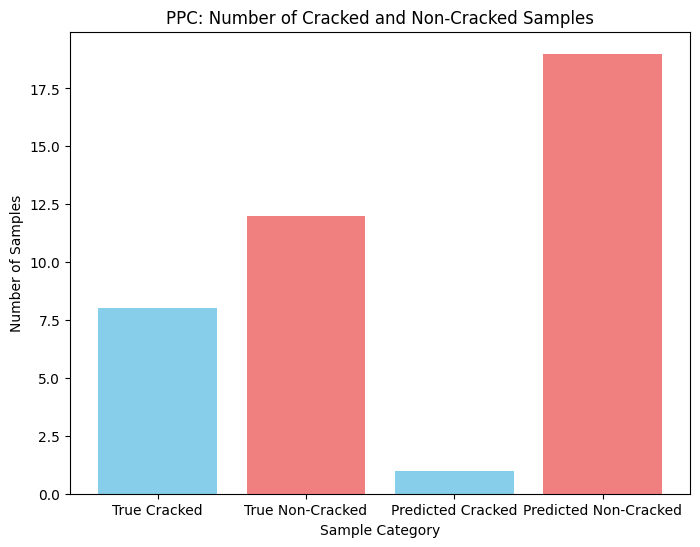

In [103]:
# prompt: plot number of non cracked and cracked in both actual and predicted in ppc

import matplotlib.pyplot as plt
cracked_true_ppc = sum(y_test_binary)
non_cracked_true_ppc = len(y_test_binary) - cracked_true_ppc
cracked_pred_ppc = sum(y_pred_binary)
non_cracked_pred_ppc = len(y_pred_binary) - cracked_pred_ppc

labels = ['True Cracked', 'True Non-Cracked', 'Predicted Cracked', 'Predicted Non-Cracked']
values_ppc = [cracked_true_ppc, non_cracked_true_ppc, cracked_pred_ppc, non_cracked_pred_ppc]

plt.figure(figsize=(8, 6))
plt.bar(labels, values_ppc, color=['skyblue', 'lightcoral', 'skyblue', 'lightcoral'])
plt.title('PPC: Number of Cracked and Non-Cracked Samples')
plt.xlabel('Sample Category')
plt.ylabel('Number of Samples')
plt.show()


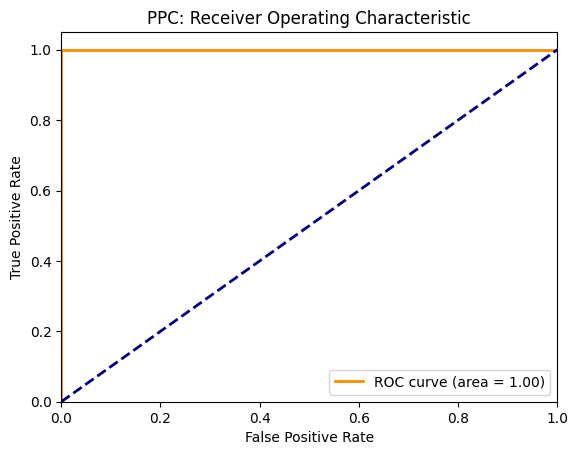

In [104]:
# prompt: plot ppc roc curve

import matplotlib.pyplot as plt
fpr_ppc, tpr_ppc, thresholds_ppc = roc_curve(y_test_binary, y_pred.flatten())
roc_auc_ppc = auc(fpr_ppc, tpr_ppc)

plt.figure()
plt.plot(fpr_ppc, tpr_ppc, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_ppc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('PPC: Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


# result